In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file = pd.read_excel('C:/Data_/excel/data_jobs_salary_all.xlsx',sheet_name='maaz_1')
print(file.info())


<class 'pandas.DataFrame'>
RangeIndex: 32672 entries, 0 to 32671
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        32672 non-null  str           
 1   job_title              32672 non-null  str           
 2   job_location           32317 non-null  str           
 3   job_via                32662 non-null  str           
 4   job_schedule_type      32531 non-null  str           
 5   job_work_from_home     32672 non-null  bool          
 6   search_location        32672 non-null  str           
 7   job_posted_date        32672 non-null  datetime64[us]
 8   job_no_degree_mention  32672 non-null  bool          
 9   job_health_insurance   32672 non-null  bool          
 10  job_country            32672 non-null  str           
 11  salary_rate            32672 non-null  str           
 12  salary_year_avg        22036 non-null  float64       
 13  salary_hour_

In [83]:
con_1=pd.read_excel('C:/Users/Maaz/Desktop/maaz.xlsx',sheet_name='no_1')    #Dummy Data
con_1


,job_id,job_title,company_name,job_location
0,1,Data Scientist,Google,"Mountain View, CA"
1,2,Software Engineer,Microsoft,"Redmond, WA"
2,3,Product Manager,Apple,"Cupertino, CA"
3,4,Marketing Director,Nike,"Beaverton, OR"
4,5,HR Manager,Starbucks,"Seattle, WA"


In [84]:
con_2=pd.read_excel('C:/Users/Maaz/Desktop/maaz.xlsx',sheet_name='no_2')   #Dummy Data
con_2

,job_id,company_name,industry,company_size
0,1,Google,Technology,"100,000+"
1,2,Microsoft,Technology,"100,000+"
2,3,Apple,Technology,"100,000+"
3,4,Nike,Apparel,"75,000+"
4,5,Starbucks,Apparel,"145,000+"


In [85]:
con_1.merge(con_2, on='company_name').drop(columns='job_id_x')       #Dummy Data

,job_title,company_name,job_location,job_id_y,industry,company_size
0,Data Scientist,Google,"Mountain View, CA",1,Technology,"100,000+"
1,Software Engineer,Microsoft,"Redmond, WA",2,Technology,"100,000+"
2,Product Manager,Apple,"Cupertino, CA",3,Technology,"100,000+"
3,Marketing Director,Nike,"Beaverton, OR",4,Apparel,"75,000+"
4,HR Manager,Starbucks,"Seattle, WA",5,Apparel,"145,000+"


In [86]:
file['job_posted_month'] = file['job_posted_date'].dt.strftime('%B')
file['month_no']=pd.to_datetime(file['job_posted_date'],format='%B').dt.month
file_pivot=file.sort_values('month_no',inplace=True)
file_pivot=file.set_index('job_posted_date',inplace=True)
file_pivot=file.pivot_table(index='job_posted_month',columns='job_title_short',aggfunc='size')
file_pivot
file_pivot.to_excel('maaz.xlsx')

In [87]:
import random

# Set seed for reproducibility
random.seed(42)

# Define job titles
job_titles = ['Front-End Developer', 'Back-End Developer', 'Full-Stack Developer', 'UI/UX Designer']

# Define months
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# Define ranges for random data
ranges = {
    'Front-End Developer': (11000, 15000),
    'Back-End Developer': (8000, 10000),
    'Full-Stack Developer': (5000, 7500),
    'UI/UX Designer': (4000, 5000)
}

# Generate random data
data = {}
for job_title in job_titles:
    data[job_title] = [random.randint(ranges[job_title][0], ranges[job_title][1]) for _ in months]

# Create DataFrame
df_US_software_pivot = pd.DataFrame(data, index=months)
df_US_software_pivot.index.name = "job_posted_month"

df_US_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [88]:
megred_data=file_pivot.merge(df_US_software_pivot,on="job_posted_month")
top_5=megred_data.sum().sort_values(ascending=False).head().index.tolist()
megred_data[top_5]

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer,Data Analyst
job_posted_month,,,,,
April,14037,9209,7232,4220,753
August,11571,8191,7413,4104,1031
December,14033,9232,6731,4367,663
February,11456,9116,7298,4284,691
January,13619,9827,5108,4348,982
July,11914,8061,6839,4344,856
June,12003,8065,5902,4781,933
March,11102,8178,5814,4159,776
May,12126,8864,6718,4980,746


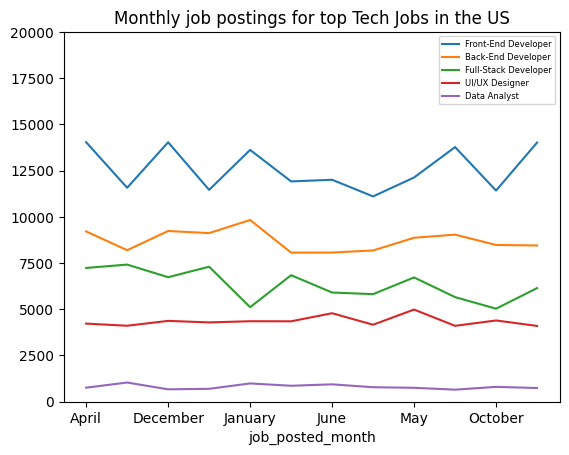

In [89]:
megred_data=file_pivot.merge(df_US_software_pivot,on="job_posted_month")
top_5=megred_data.sum().sort_values(ascending=False).head().index.tolist()
megred_data[top_5].plot(kind='line')
plt.legend(fontsize=6)
plt.ylim(0,20000)
plt.title('Monthly job postings for top Tech Jobs in the US')
plt.show()